# Test en Machine Learning
## Prétraitement de données

### 1- faites les importations des bibliothèques nécessaires

In [16]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### 2- importer les données du fichier "dataset_ProjetML_2026.csv"

In [17]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### 3- afficher un échontillon du dataframe

In [3]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


### 4- afficher toutes les variables du dataset et leurs types respectifs

In [4]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

In [5]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### 5-Afficher le nombre de lignes et de colonnes du dataframe

In [7]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


In [8]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [9]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

In [10]:
duplicates = df[df.duplicated()]
len(duplicates)

776

In [11]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### 6- Quelles sont les colonnes qui  contiennent des valeurs nulls ? Endéduire le nombre de valeurs nulls

In [12]:
print(df.isna().sum())

Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64


### 7-remplacer les valeurs manquantes dans la colonne "" par la moyenne de la colonne

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [14]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [15]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.median()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix"] = df.groupby("Categorie")["Prix"].transform(lambda x: x.fillna(x.median()))


KeyError: 'Column not found: Prix'

In [ ]:
df["Rigidite"] = df.groupby("Source")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Source")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Source")["Opacite"].transform(lambda x: x.fillna(x.median()))

In [ ]:
print(df.isna().sum())

Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           492
Source              510
Rapport_Collecte      0
dtype: int64


### Catégorielle

In [ ]:
print(df["Categorie"].mode())
print(df["Source"].mode())


0    Plastique
Name: Categorie, dtype: object
0    Collecte_Citoyenne
Name: Source, dtype: object


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


### 9- Sachant que la colonne "" est la cible, déduire si le dataset est équilibré ou non?

In [ ]:
df["Categorie"].value_counts()

Categorie
Plastique    3309
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [ ]:
#OUI la dataset est globalement équilibré car Les classes ne sont pas très éloignées

In [ ]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

<Axes: >

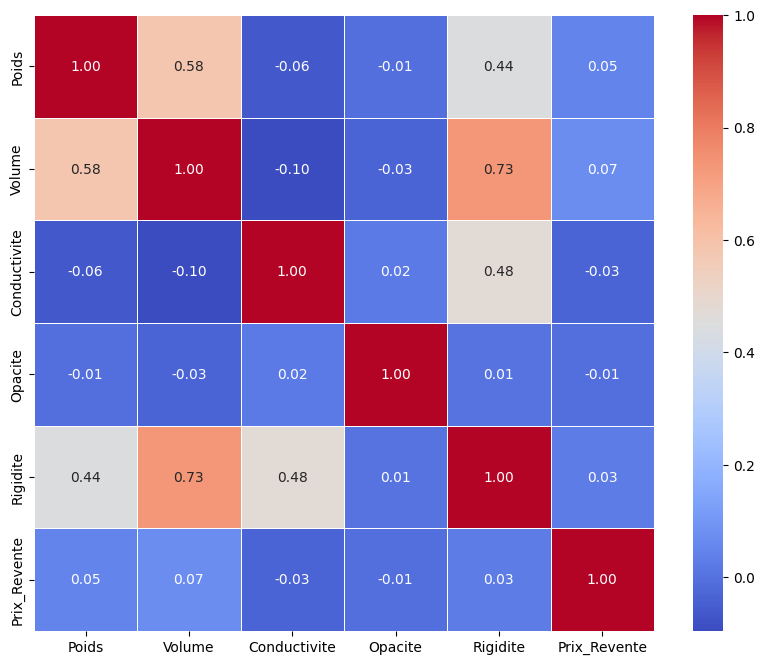

In [ ]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

### 11- Chercher les colonnes qui ont des valeurs abbérantes en affichant le boxplot pour tout le dataset

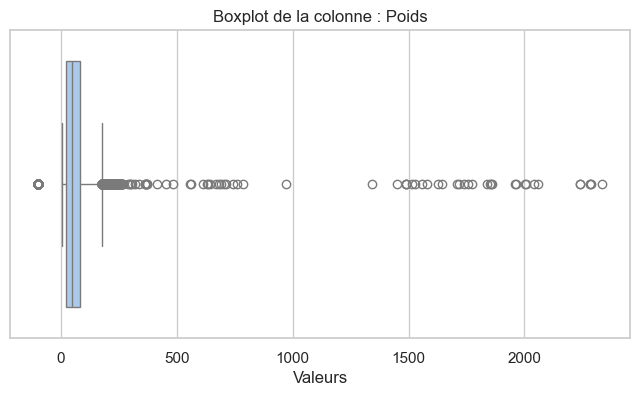

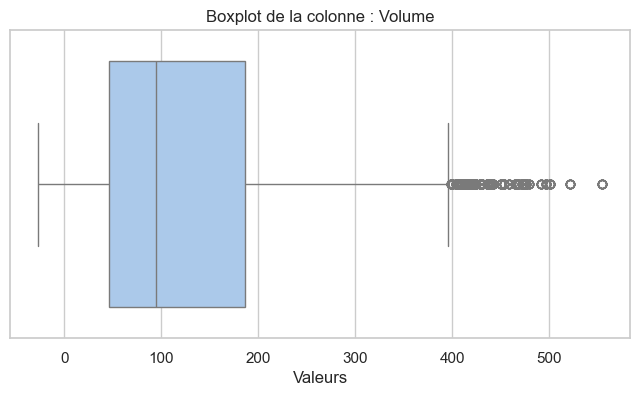

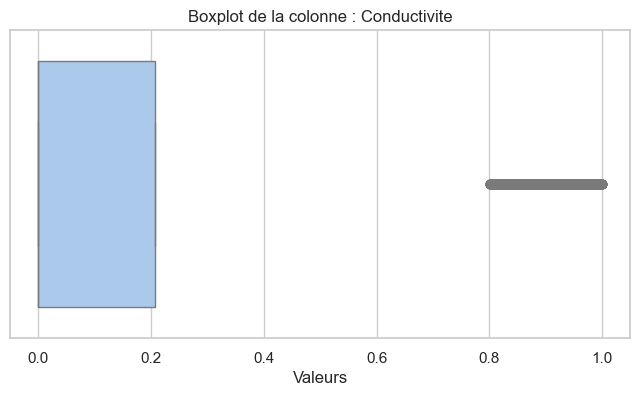

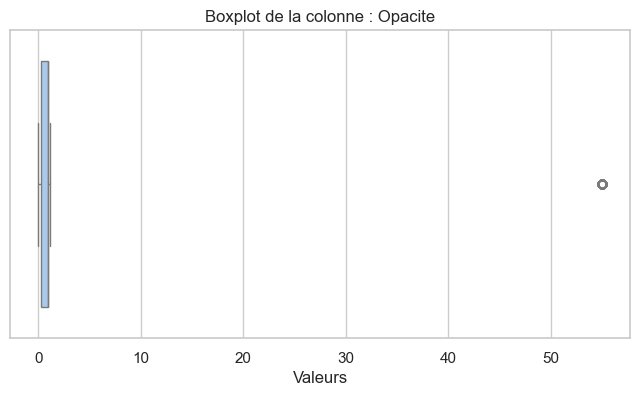

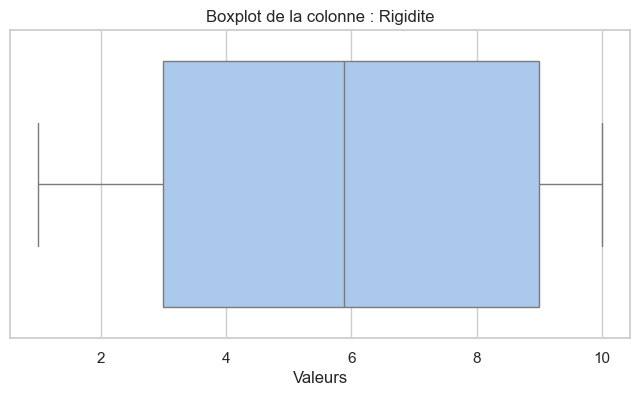

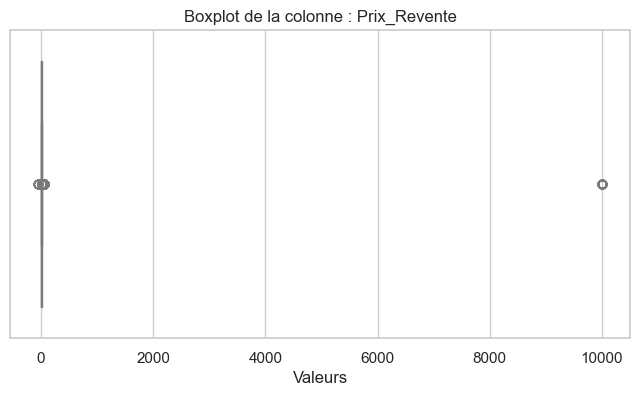

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

In [ ]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


### 12- Nous allons traiter les valeurs abbérantes que la colonne "" en remplaçant ces valeurs par la médiane

#### a-calculer les 4 quartiles (Q1,Q3,IRQ) et Sup, Inf

In [ ]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR


#### b-remplacer les VA par la mediane de la colonne

In [ ]:
outliers = df[(df['Poids'] < inf) | (df['Poids'] > sup)]
print(outliers)
for i in df['Poids']:
    if i >=sup or i<=inf:
        df['Poids']=df['Poids'].replace(i,np.median(df['Poids']))

Empty DataFrame
Columns: [Poids, Volume, Conductivite, Opacite, Rigidite, Prix_Revente, Categorie, Source, Rapport_Collecte]
Index: []


#### c-vérifier la modification des VA

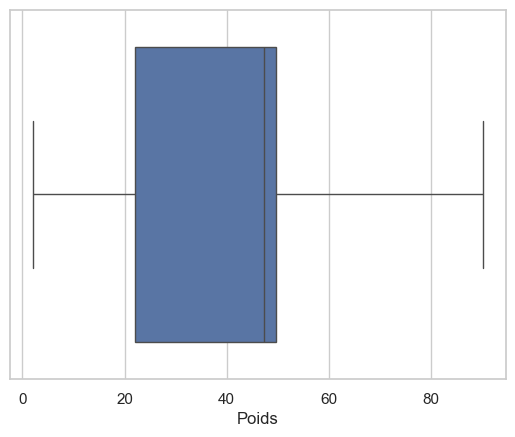

In [ ]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

### 13- supprimer les VA de la colonne ''

In [ ]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


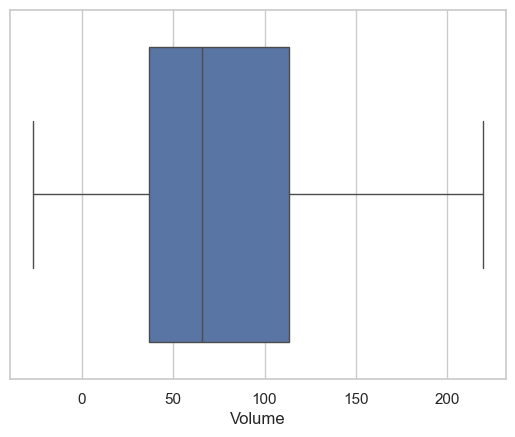

In [ ]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

### *13- Traiter les VA de la colonne 

In [ ]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


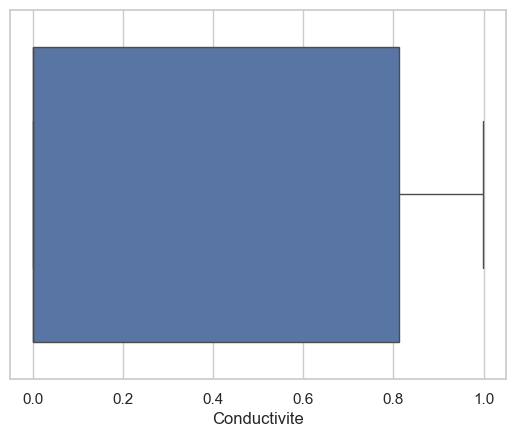

In [ ]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

In [ ]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


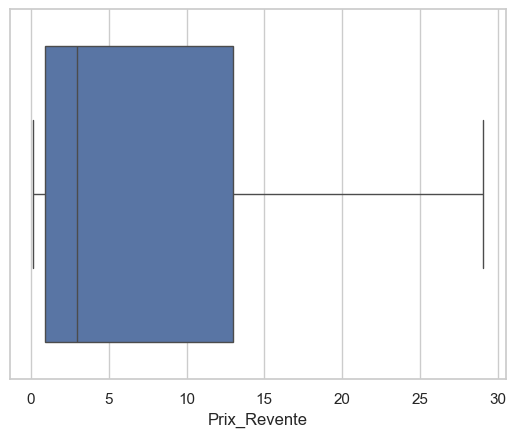

In [ ]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

Text(0, 0.5, 'Volume')

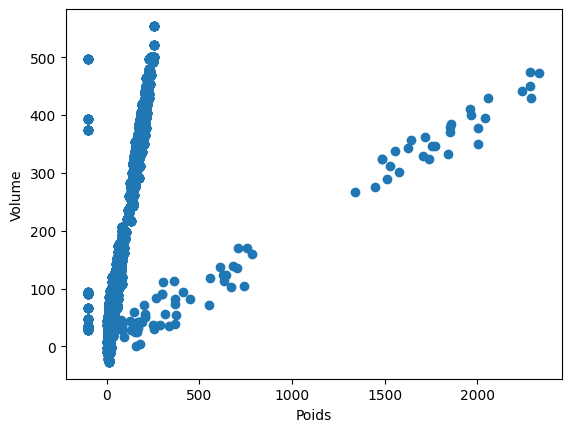

In [ ]:
plt.scatter(x=df['Poids'],y=df['Volume'])
plt.xlabel('Poids')
plt.ylabel('Volume')


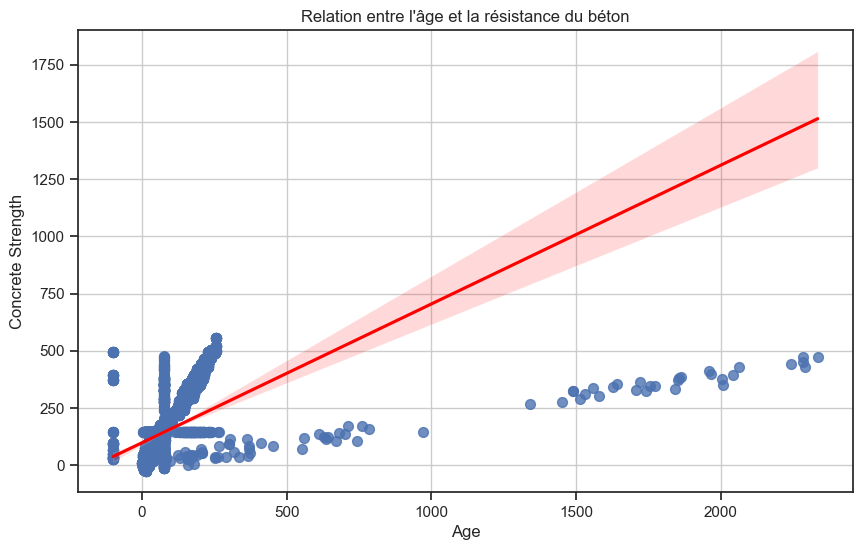

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre l\'âge et la résistance du béton')
plt.xlabel('Age')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

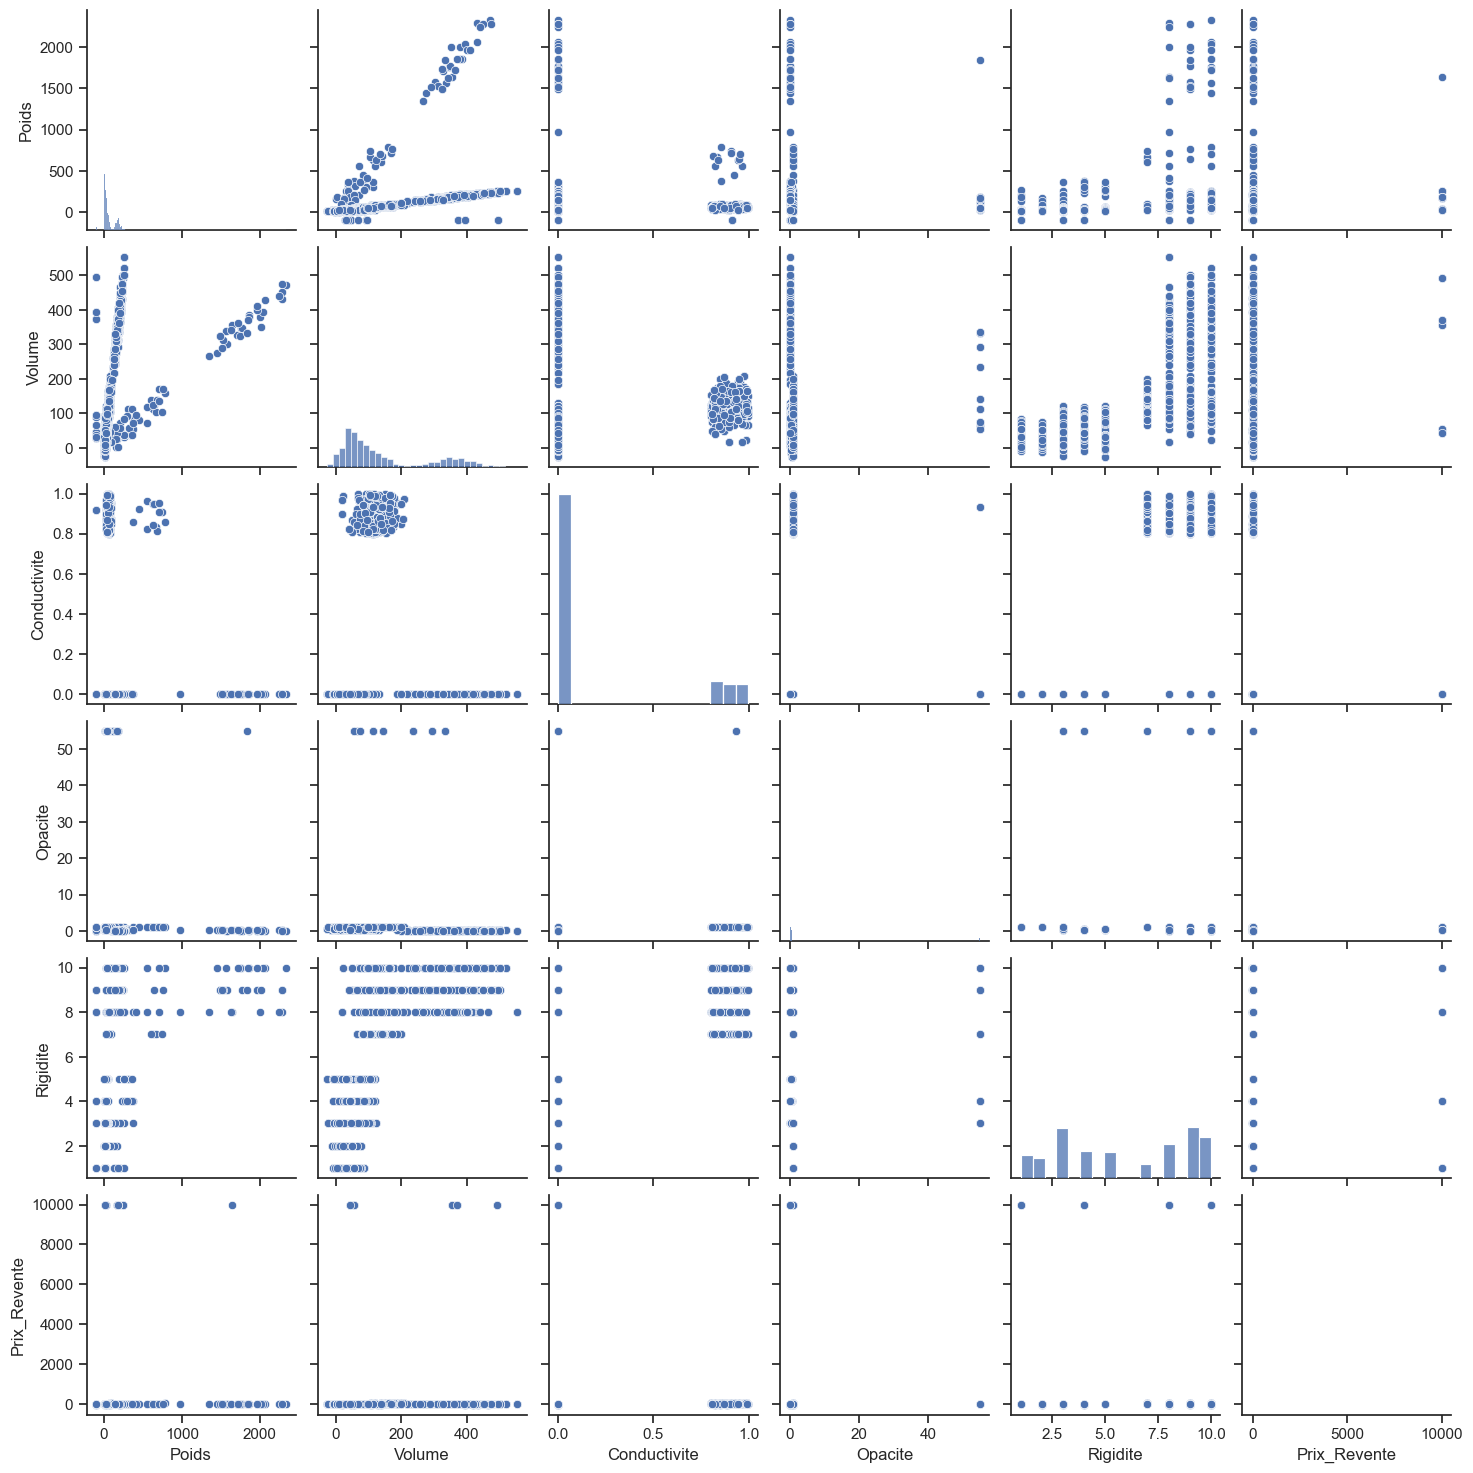

In [ ]:
sns.set(style='ticks')
sns.pairplot(df)

### 14- affecter à Y (cible) la dernière colonne () et le reste du dataframe au entrées X

In [ ]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0           Papier
1        Plastique
2            Verre
3           Papier
4           Papier
           ...    
10495        Verre
10496        Verre
10497       Papier
10498    Plastique
10499        Verre
Name: Categorie, Length: 10500, dtype: object

Entrées X :
            Poids      Volume  Conductivite   Opacite   Rigidite  \
0       16.708780   70.940977           0.0  1.000000   1.000000   
1       47.277476   64.702925           0.0  1.160388   3.000000   
2       77.796501  317.415183           0.0  1.160388   9.000000   
3       77.796501   21.474391           0.0  1.160388   1.000000   
4       77.796501   59.462176           0.0  1.000000   5.886643   
...           ...         ...           ...       ...        ...   
10495  191.018619  418.800912           0.0  0.019307   9.000000   
10496  149.052713  287.519460           0.0  0.157940  10.000000   
10497   15.572667   50.148243           0.0  1.000000   2.000000   
10498   26.707263   44.008897           0.

In [ ]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0        0.835439
1        4.727748
2        4.211790
3        0.442067
4        0.723004
           ...   
10495    5.730559
10496    4.471581
10497    0.778633
10498    2.670726
10499    4.400482
Name: Prix_Revente, Length: 9964, dtype: float64

Entrées X :
            Poids      Volume  Conductivite   Opacite   Rigidite  Categorie  \
0       16.708780   70.940977           0.0  1.000000   1.000000     Papier   
1       47.277476   64.702925           0.0  1.142706   3.000000  Plastique   
2       77.946229  317.415183           0.0  1.142706   9.000000      Verre   
3       77.946229   21.474391           0.0  1.142706   1.000000     Papier   
4       77.946229   59.462176           0.0  1.000000   5.892047     Papier   
...           ...         ...           ...       ...        ...        ...   
10495  191.018619  418.800912           0.0  0.019307   9.000000      Verre   
10496  149.052713  287.519460           0.0  0.157940  10.000000      Verre   
10497   15.572667  

In [ ]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [ ]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
10046  38.616361   80.013930      0.000000  0.358525       3.0      3.861636   
4678   64.413362  124.138568      0.947745  1.000000       9.0     58.587857   
1189   41.591103  116.384946      0.854843  1.000000       9.0     12.477331   
2196   84.571691  199.164159      0.849508  1.000000       7.0     25.371507   
5334   66.899582  120.244857      0.902444  1.000000       7.0     20.069875   

        Source  
10046  Usine_A  
4678   Usine_B  
1189   Usine_B  
2196   Usine_A  
5334   Usine_B  

Echantillon de Y :
9595    Plastique
1035        Verre
6682       Papier
7416    Plastique
9837        Verre
Name: Categorie, dtype: object


In [ ]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
6692  209.367720  398.605175      0.000000  0.002298  8.000000      Verre   
3908   18.365660  -10.673729      0.000000  1.000000  3.000000     Papier   
6271   48.466265  101.378184      0.000000  0.242751  4.000000  Plastique   
8051   34.958921   80.785045      0.953899  1.000000  5.892047      Métal   
4430  164.724143  344.998910      0.000000  0.128576  9.000000      Verre   

                  Source  
6692             Usine_A  
3908  Collecte_Citoyenne  
6271             Usine_B  
8051          Centre_Tri  
4430             Usine_A  

Echantillon de Y :
3506     2.794713
6650     0.657681
6501     4.258768
4108    11.256033
5242     1.455536
Name: Prix_Revente, dtype: float64


### 17- transformer les colonnes catégoriques en numérique

In [ ]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)

X_regg = ct.fit_transform(X_regg)

### - Transformer X et Y en tableau numpy

In [ ]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)

print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (10500, 10)
Shape de Y : (10500,)


In [ ]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (9964, 13)
Shape de Y : (9964,)


### 18- Vérifier cette transformation

In [ ]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 1.16038817e+00,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.77965008e+01, 3.17415183e+02, 0.00000000e+00, 1.16038817e+00,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        7.77965008e+01, 2.14743907e+01, 0.00000000e+00, 1.16038817e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.77965008e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        5.88664253e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [ ]:
Y_class

array([1, 2, 3, ..., 1, 2, 3])

In [ ]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 1.14270601e+00,
        3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.79462287e+01, 3.17415183e+02, 0.00000000e+00, 1.14270601e+00,
        9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        7.79462287e+01, 2.14743907e+01, 0.00000000e+00, 1.14270601e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+

In [ ]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### 19- Subdiviser la dataset en deux parties train et test

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (8400, 10)
x_test: (2100, 10)
y_train: (8400,)
y_test: (2100,)
y_train mean: 1.5907142857142857
y_test mean: 1.5866666666666667


In [ ]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (7971, 13)
x_test: (1993, 13)
y_train: (7971,)
y_test: (1993,)
y_train: 54.10829579592715
y_test: 76.50385169278721


### 20- Mettre à l'échelle par standardisation les variables en entrée X_train et X_test

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [ ]:
print(x_train[:5])

[[ 0.04446722  0.91377162 -0.14972402 -1.54572979 -1.09216363  0.83475133
   0.52171874  0.57407122 -0.66673831  1.58983898]
 [ 0.41722807 -0.74594213  0.6030946  -0.66154144 -1.23956229 -1.50287061
  -1.23735285 -0.61453878  0.30463008  0.75341946]
 [ 0.83868939  0.86018264  0.66388059  0.81026004 -0.45887685 -1.01758478
  -0.81227081  0.72508104 -1.17953018 -1.15545179]
 [-1.19969993  0.19344857 -1.01968336  1.30986517  0.02308066  0.62490359
   1.37581721 -0.18455144  1.45841876 -0.07434533]
 [ 0.74076545 -0.32066763  0.62058169  1.79521136  0.53450565  0.88765543
  -0.8219287   0.49774309 -0.9300205   0.23007076]]


In [ ]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [ ]:
print(x_train_reg[:5])

[[-5.41436789e-01  1.50559067e+00 -5.66581197e-01 -5.37560731e-01
   1.88061434e+00 -5.33293720e-01 -6.74015327e-01 -5.70831239e-01
  -6.24667431e-02 -7.17589654e-02  2.06094499e+00 -2.67109966e-02
   1.36079245e+00]
 [-5.41436789e-01 -6.64191149e-01  1.76497209e+00 -5.37560731e-01
  -5.31741133e-01 -5.33293720e-01 -6.74015327e-01  1.75183124e+00
   1.34460518e-04  1.53371428e+00 -5.78895120e-01 -2.17032359e-01
   1.02933041e+00]
 [ 1.84693767e+00 -6.64191149e-01 -5.66581197e-01 -5.37560731e-01
  -5.31741133e-01 -5.33293720e-01  1.48364579e+00 -5.70831239e-01
  -4.61608764e-01 -5.98074690e-01 -5.99876940e-03 -1.31698464e-01
  -6.27979789e-01]
 [ 1.84693767e+00 -6.64191149e-01 -5.66581197e-01 -5.37560731e-01
  -5.31741133e-01 -5.33293720e-01  1.48364579e+00 -5.70831239e-01
   1.34460518e-04 -5.19628307e-02  1.74765405e+00 -2.67109966e-02
   1.02933041e+00]
 [ 1.84693767e+00 -6.64191149e-01 -5.66581197e-01 -5.37560731e-01
  -5.31741133e-01 -5.33293720e-01  1.48364579e+00 -5.70831239e-01


# Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report
import numpy as np

# --- Imputation des NaN (remplacement par la moyenne de chaque colonne) ---
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test  = imputer.transform(x_test)       # transform seulement, pas fit !

# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))

# --- Aperçu des 10 premières prédictions ---
print("\nAperçu des 10 premières prédictions:")
for i in range(10):
    print(f"  [{i}] Vérité: {y_test_eval[i]}  →  Prédiction: {y_pred_knn[i]}")


Confusion Matrix:
 [[463   0   5   0]
 [  0 433  11   0]
 [ 17  28 608  23]
 [  0   0   5 507]]

Accuracy  : 0.9576
Recall    : 0.9635
Precision : 0.9568

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       468
           1       0.94      0.98      0.96       444
           2       0.97      0.90      0.93       676
           3       0.96      0.99      0.97       512

    accuracy                           0.96      2100
   macro avg       0.96      0.96      0.96      2100
weighted avg       0.96      0.96      0.96      2100


Aperçu des 10 premières prédictions:
  [0] Vérité: 2  →  Prédiction: 0
  [1] Vérité: 2  →  Prédiction: 2
  [2] Vérité: 1  →  Prédiction: 1
  [3] Vérité: 3  →  Prédiction: 3
  [4] Vérité: 2  →  Prédiction: 2
  [5] Vérité: 2  →  Prédiction: 2
  [6] Vérité: 3  →  Prédiction: 3
  [7] Vérité: 3  →  Prédiction: 3
  [8] Vérité: 2  →  Prédiction: 2
  [9] Vérité: 2  →  Prédiction: 2


# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 5}
Meilleur score     : 0.9533813806162502

Confusion Matrix KNN optimisé:
 [[467   0   1   0]
 [  0 431  13   0]
 [ 17  29 607  23]
 [  1   0   0 511]]
Accuracy  : 0.9600
Recall    : 0.9661
Precision : 0.9586

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       468
           1       0.94      0.97      0.95       444
           2       0.98      0.90      0.94       676
           3       0.96      1.00      0.98       512

    accuracy                           0.96      2100
   macro avg       0.96      0.97      0.96      2100
weighted avg       0.96      0.96      0.96      2100



# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[465   0   3   0]
 [  0 433  11   0]
 [ 16  28 609  23]
 [  0   0   5 507]]
Accuracy  : 0.9590
Recall    : 0.9650
Precision : 0.9581

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       468
           1       0.94      0.98      0.96       444
           2       0.97      0.90      0.93       676
           3       0.96      0.99      0.97       512

    accuracy                           0.96      2100
   macro avg       0.96      0.96      0.96      2100
weighted avg       0.96      0.96      0.96      2100



## Importance des features

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[468   0   0   0]
 [  0 440   4   0]
 [ 16  21 617  22]
 [  0   0   4 508]]
Accuracy  : 0.9681
Recall    : 0.9740
Precision : 0.9668

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       468
           1       0.95      0.99      0.97       444
           2       0.99      0.91      0.95       676
           3       0.96      0.99      0.98       512

    accuracy                           0.97      2100
   macro avg       0.97      0.97      0.97      2100
weighted avg       0.97      0.97      0.97      2100



In [ ]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 1.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]



les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(classification_report(y_test, y_predictSVM_l))

[[452   0  16   0]
 [  0 366  78   0]
 [ 16  82 555  23]
 [  4   0   3 505]]
Accuracy linear SVM 0.894
Precision linear SVM 0.896
Recall linear SVM 0.899
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       468
           1       0.82      0.82      0.82       444
           2       0.85      0.82      0.84       676
           3       0.96      0.99      0.97       512

    accuracy                           0.89      2100
   macro avg       0.90      0.90      0.90      2100
weighted avg       0.89      0.89      0.89      2100



# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [ ]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))

[[450   0  18   0]
 [  0 363  81   0]
 [ 16  86 552  22]
 [  1   0   9 502]]
Accuracy Logistic Regression 0.889
Precision Logistic Regression 0.892
Recall Logistic Regression 0.894


# Sommary

In [ ]:
print("| Algorithm         | Accuracy   | Recall     | Precision  |")
print("| ----------------- | ---------- | ---------- | ---------- |")
print("| Optimized kNN     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(knn_op_acc, knn_op_rec, knn_op_prec))
print("| Decision Tree     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(accur_dt, rec_dt, pres_dt))
print("| Random Forest     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(rf_acc, rf_rec, rf_prec))
print("| Linear SVM        | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(svm_acc, svm_rec, svm_prec))
print("| Logistic Reg      | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(LR_acc, LR_rec, LR_prec))

| Algorithm         | Accuracy   | Recall     | Precision  |
| ----------------- | ---------- | ---------- | ---------- |
| Optimized kNN     | 0.960    | 0.966    | 0.959    |
| Decision Tree     | 0.959    | 0.965    | 0.958    |
| Random Forest     | 0.968    | 0.974    | 0.967    |
| Linear SVM        | 0.894    | 0.899    | 0.896    |
| Logistic Reg      | 0.889    | 0.894    | 0.892    |


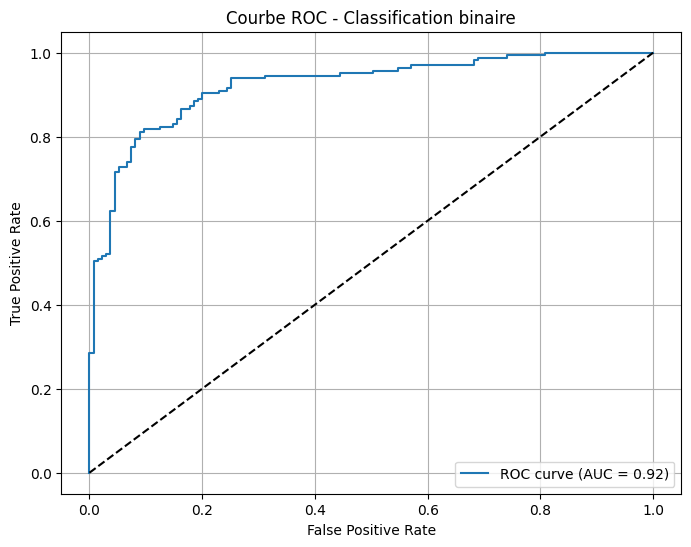

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modèle
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# Probabilités de la classe positive
y_score = model.predict_proba(x_test)[:, 1]

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Affichage
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Classification binaire")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Regression

In [ ]:
# =========================================================
# 1) Importation des bibliothèques
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 2) Charger le dataset
# =========================================================
df = pd.read_csv("dataset_ProjetML_2026.csv")

print("Dimensions du dataset :", df.shape)
print(df.head())

# =========================================================
# 3) Supprimer les lignes où la cible est manquante
# =========================================================
df = df.dropna(subset=["Prix_Revente"]).copy()

# =========================================================
# 4) Définir X et y
# =========================================================
X = df.drop("Prix_Revente", axis=1)
y = df["Prix_Revente"]

# =========================================================
# 5) Définir les colonnes
# =========================================================
numeric_features = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
categorical_features = ["Categorie", "Source"]
text_feature = "Rapport_Collecte"

# =========================================================
# 6) Prétraitement
# =========================================================

# Pipeline pour les colonnes numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les colonnes catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pipeline pour la colonne texte
text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(max_features=300))
])

# Combinaison de tous les prétraitements
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("txt", text_transformer, text_feature)
])

# =========================================================
# 7) Division Train / Test
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 8) Définir plusieurs modèles de régression
# =========================================================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# =========================================================
# 9) Entraîner et évaluer chaque modèle
# =========================================================
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modele": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })
    
    print(f"\n===== {name} =====")
    print("MAE  =", mae)
    print("MSE  =", mse)
    print("RMSE =", rmse)
    print("R2   =", r2)

# =========================================================
# 10) Tableau comparatif des résultats
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("\nTableau des performances :")
print(results_df)

# =========================================================
# 11) Choisir le meilleur modèle
# =========================================================
best_model_name = results_df.iloc[0]["Modele"]
print("\nMeilleur modèle :", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

# =========================================================
# 12) Prédictions sur l'ensemble de test
# =========================================================
y_pred_best = best_pipeline.predict(X_test)

# =========================================================
# 13) Générer une nouvelle colonne avec le prix prédit
# =========================================================
X_test_result = X_test.copy()
X_test_result["Prix_Revente_Reel"] = y_test.values
X_test_result["Prix_Revente_Predit"] = y_pred_best

print("\nAperçu des prédictions :")
print(X_test_result.head())

# =========================================================
# 14) Sauvegarder le résultat dans un fichier CSV
# =========================================================
X_test_result.to_csv("resultats_regression_prix_revente.csv", index=False)

print("\nFichier sauvegardé : resultats_regression_prix_revente.csv")

Dimensions du dataset : (10500, 9)
       Poids      Volume  Conductivite  Opacite  Rigidite  Prix_Revente  \
0  16.708780   70.940977           0.0      1.0       1.0      0.835439   
1  47.277476   64.702925           0.0      NaN       3.0      4.727748   
2        NaN  317.415183           0.0      NaN       9.0      4.211790   
3        NaN   21.474391           0.0      NaN       1.0      0.442067   
4        NaN   59.462176           0.0      1.0       NaN      0.723004   

   Categorie      Source                                   Rapport_Collecte  
0     Papier         NaN  Lot de papier récupéré dans un site non rensei...  
1  Plastique     Usine_A  Lot plastique à l'Usine A. Volume 64.7 L, poid...  
2      Verre     Usine_B  Bris de verre ou contenants en provenance de l...  
3     Papier  Centre_Tri  Feuilles et cartons collectés au Centre de Tri...  
4     Papier     Usine_B  Déchet de type papier identifié à l'Usine B. V...  

===== LinearRegression =====
MAE  = 164.84266

# Régression linéaire

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.008119044478171245
MAE   : 129.10540604480843
MSE   : 690894.7587506416
RMSE  : 831.2007932808062
MAPE  : 25.873408299695406
MEDAE : 46.66904845609519
          0         1         2         3         4         5         6  \
0 -0.541437 -0.664191 -0.566581  1.860255  1.880614 -0.533294 -0.674015   
1 -0.541437 -0.664191  1.764972 -0.537561  1.880614 -0.533294 -0.674015   
2 -0.541437  1.505591 -0.566581 -0.537561 -0.531741 -0.533294  1.483646   
3 -0.541437 -0.664191  1.764972 -0.537561 -0.531741 -0.533294 -0.674015   
4  1.846938 -0.664191 -0.566581 -0.537561 -0.531741 -0.533294 -0.674015   

          7         8         9        10        11        12    prix_reel  \
0 -0.570831 -0.451166 -0.961265  1.906914 -0.026711  0.697868     6.672856   
1 -0.570831 -0.335028 -0.311799  1.766505 -0.026711  1.029330    10.973280   
2 -0.570831 -0.522848 -0.614556 -0.578895 -0.140902 -0.959442     1.339517   
3  1.751831  1.407831  2.622586 -0.578895 -0

# Coefficients

### NLP

In [18]:
#Nettoyage du texte
import re

def clean_text(text):
    text = str(text).lower()  # minuscule
    text = re.sub(r'[^\w\s]', '', text)  # enlever ponctuation
    return text

df["clean_text"] = df["Rapport_Collecte"].apply(clean_text)

In [19]:
#Étape 2 : Tokenization (découper en mots)
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

In [20]:
#Étape 3 : Supprimer les mots inutiles (stopwords)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(tokens):
    return [word for word in tokens if word not in ENGLISH_STOP_WORDS]

df["tokens"] = df["tokens"].apply(remove_stopwords)

In [23]:
#Étape 4 : Stemming (optionnel) pour réduire les mots
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["tokens"] = df["tokens"].apply(lambda x: [stemmer.stem(word) for word in x])

In [ ]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(df["clean_text"])

In [ ]:
#Combiner avec ton dataset
import pandas as pd

X_text_df = pd.DataFrame(X_text.toarray(), columns=tfidf.get_feature_names_out())

df = pd.concat([df.reset_index(drop=True), X_text_df], axis=1)

In [ ]:
#Extraire volume
def extract_volume(text):
    match = re.search(r'(\d+)\s*L', str(text))
    return float(match.group(1)) if match else None

df["Volume_text"] = df["Rapport_Collecte"].apply(extract_volume)

In [ ]:
#Extraire catégorie
def detect_categorie(text):
    text = str(text).lower()
    if "plastique" in text:
        return "plastique"
    elif "verre" in text:
        return "verre"
    elif "papier" in text:
        return "papier"

In [ ]:
#Trouver les lignes intéressantes
df_nlp_useful = df[
    (df["Rapport_Collecte"].notna()) &
    (
        df["Volume"].isna() |
        df["Categorie"].isna() |
        df["Poids"].isna()
    )
]

print(df_nlp_useful.head())

In [ ]:
#Analyser le texte (voir s’il contient info)
for text in df_nlp_useful["Rapport_Collecte"].head(10):
    print(text)

In [ ]:
#Détecter volume dans texte
import re

df["has_volume_in_text"] = df["Rapport_Collecte"].apply(
    lambda x: bool(re.search(r'\d+\s*L', str(x)))
)

print(df["has_volume_in_text"].value_counts())

In [ ]:
#Détecter catégorie
def has_category(text):
    text = str(text).lower()
    return any(word in text for word in ["plastique", "verre", "papier"])

df["has_category_in_text"] = df["Rapport_Collecte"].apply(has_category)


In [ ]:
#Comparaison intelligente
df_test = df[
    (df["Volume"].isna()) &
    (df["has_volume_in_text"] == True)
]

print(len(df_test))

In [ ]:
#Volume
#Remplissage automatique depuis NLP
def extract_volume(text):
    match = re.search(r'(\d+)\s*L', str(text))
    return float(match.group(1)) if match else None

df["Volume_text"] = df["Rapport_Collecte"].apply(extract_volume)

df["Volume"] = df["Volume"].fillna(df["Volume_text"])

In [ ]:
#Catégorie
def detect_categorie(text):
    text = str(text).lower()
    if "plastique" in text:
        return "plastique"
    elif "verre" in text:
        return "verre"
    elif "papier" in text:
        return "papier"
    return None

df["Categorie"] = df["Categorie"].fillna(df["Rapport_Collecte"].apply(detect_categorie))

In [ ]:
#Vérifier si ça a amélioré
print(df.isnull().sum())